# Monthly Rainfall Forecasting with SARIMAX

## Objective

This project forecasts **monthly rainfall in Belfast** using a seasonal time-series model with meteorological predictors.

The main question is:

> **Do external weather variables improve rainfall forecasting beyond rainfall history and seasonality alone?**

The models compared are:

1. Seasonal Naive baseline
2. SARIMA
3. SARIMAX

The SARIMAX model uses:

- minimum temperature
- maximum temperature
- humidity
- cloud cover
- wind speed

The final SARIMAX specification is selected using a **validation period inside the training data**. The final 24 months are kept as an untouched test set.


## 1. SARIMAX concept

SARIMAX means:

**Seasonal ARIMA with Exogenous Variables**

It is written as:

**SARIMAX (p, d, q) (P, D, Q, m) + X**

The first two parts model the target time series itself:

- **p**: autoregressive order
- **d**: ordinary differencing order
- **q**: moving-average order
- **P, D, Q**: seasonal counterparts
- **m**: seasonal period

The additional **X** variables are external predictors.

For monthly rainfall:

**m = 12**

In this project:

**y = monthly rainfall**

**X = temperature + humidity + cloud cover + wind speed**

The key idea is to test whether adding `X` improves forecasting over SARIMA alone.


## 2. Import libraries

Only the packages required for the analysis are imported here.


In [1]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## 3. Load the dataset

The project uses the Kaggle **2M+ Daily Weather History UK** dataset.

To reduce memory use, only the columns needed for this project are loaded.

Belfast is used as the study location because it provides a long daily record with complete values for the selected variables over the study period.


In [2]:
DATA_PATH = "/kaggle/input/datasets/jakewright/2m-daily-weather-history-uk/all_weather_data.parquet"

columns = [
    "location",
    "date",
    "min_temp °c",
    "max_temp °c",
    "rain mm",
    "humidity %",
    "cloud_cover %",
    "wind_speed km/h"
]

df = pd.read_parquet(
    DATA_PATH,
    columns=columns
)

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Dataset shape:", df.shape)
print("First date:", df["date"].min())
print("Last date :", df["date"].max())
print("Locations :", df["location"].nunique())

df.head()


Dataset shape: (2836186, 8)
First date: 2009-01-01 00:00:00
Last date : 2024-11-12 00:00:00
Locations : 504


,location,date,min_temp °c,max_temp °c,rain mm,humidity %,cloud_cover %,wind_speed km/h
0,Holywood,2009-01-01,0.0,3.0,0.0,86.0,14.0,12.0
1,North Cray,2009-01-01,-3.0,2.0,0.0,93.0,44.0,8.0
2,Portknockie,2009-01-01,2.0,4.0,0.8,88.0,87.0,10.0
3,Blairskaith,2009-01-01,-3.0,1.0,0.0,86.0,43.0,12.0
4,Onehouse,2009-01-01,-1.0,3.0,0.0,91.0,63.0,7.0


## 4. Select Belfast and create a daily time series

Time-series models require observations in chronological order.

We select Belfast, use `date` as the index, and reindex to a complete daily calendar. This allows us to detect missing calendar days rather than only missing values in existing rows.


In [3]:
LOCATION = "Belfast"

daily = (
    df[df["location"] == LOCATION]
    [
        [
            "date",
            "rain mm",
            "min_temp °c",
            "max_temp °c",
            "humidity %",
            "cloud_cover %",
            "wind_speed km/h"
        ]
    ]
    .set_index("date")
    .sort_index()
)

print("Duplicate dates:", daily.index.duplicated().sum())
print("Observed daily rows:", len(daily))
print("Start:", daily.index.min())
print("End  :", daily.index.max())

daily_full = daily.asfreq("D")

print("\nMissing values after daily reindexing:")
print(daily_full.isna().sum())


Duplicate dates: 0
Observed daily rows: 5638
Start: 2009-01-01 00:00:00
End  : 2024-06-12 00:00:00

Missing values after daily reindexing:
rain mm            4
min_temp °c        4
max_temp °c        4
humidity %         4
cloud_cover %      4
wind_speed km/h    4
dtype: int64


## 5. Convert daily weather to monthly data

SARIMAX will be modeled at monthly frequency.

Aggregation rules:

- **Rainfall** → monthly total
- **Temperature, humidity, cloud cover, wind speed** → monthly mean

A monthly coverage check is also calculated. Months with less than **90% observed rainfall days** are removed so an incomplete month is not treated as a true monthly rainfall total.


In [4]:
monthly = pd.DataFrame({
    "rain_mm":
        daily_full["rain mm"].resample("MS").sum(min_count=1),

    "min_temp_c":
        daily_full["min_temp °c"].resample("MS").mean(),

    "max_temp_c":
        daily_full["max_temp °c"].resample("MS").mean(),

    "humidity":
        daily_full["humidity %"].resample("MS").mean(),

    "cloud_cover":
        daily_full["cloud_cover %"].resample("MS").mean(),

    "wind_speed":
        daily_full["wind_speed km/h"].resample("MS").mean()
})

monthly["observed_days"] = (
    daily_full["rain mm"]
    .resample("MS")
    .count()
)

monthly["days_in_month"] = monthly.index.days_in_month

monthly["coverage_pct"] = (
    monthly["observed_days"]
    / monthly["days_in_month"]
    * 100
)

print("Months below 90% coverage:")
display(
    monthly.loc[
        monthly["coverage_pct"] < 90,
        ["rain_mm", "observed_days", "days_in_month", "coverage_pct"]
    ]
)

monthly_clean = (
    monthly[monthly["coverage_pct"] >= 90]
    .drop(
        columns=[
            "observed_days",
            "days_in_month",
            "coverage_pct"
        ]
    )
    .copy()
)

print("\nClean monthly shape:", monthly_clean.shape)
print("Start:", monthly_clean.index.min())
print("End  :", monthly_clean.index.max())
print("\nMissing values:")
print(monthly_clean.isna().sum())


Months below 90% coverage:


,rain_mm,observed_days,days_in_month,coverage_pct
date,,,,
2024-06-01,12.3,12,30,40.0



Clean monthly shape: (185, 6)
Start: 2009-01-01 00:00:00
End  : 2024-05-01 00:00:00

Missing values:
rain_mm        0
min_temp_c     0
max_temp_c     0
humidity       0
cloud_cover    0
wind_speed     0
dtype: int64


## 6. Define the target and exogenous variables

The target is the quantity being forecast:

**y = monthly rainfall**

The exogenous matrix contains information supplied to SARIMAX:

**X = minimum temperature, maximum temperature, humidity, cloud cover, wind speed**

The future values of these external variables must be known or separately forecast when SARIMAX is used for a genuine future forecast.


In [5]:
y = monthly_clean["rain_mm"]

full_variables = [
    "min_temp_c",
    "max_temp_c",
    "humidity",
    "cloud_cover",
    "wind_speed"
]

reduced_variables = [
    "max_temp_c",
    "humidity",
    "cloud_cover",
    "wind_speed"
]

X_full = monthly_clean[full_variables]
X_reduced = monthly_clean[reduced_variables]

print("Target observations:", len(y))
print("Full X shape:", X_full.shape)
print("Reduced X shape:", X_reduced.shape)


Target observations: 185
Full X shape: (185, 5)
Reduced X shape: (185, 4)


## 7. Inspect rainfall seasonality

Monthly rainfall is plotted through time and then averaged by calendar month.

The calendar-month average helps reveal whether the expected rainfall level changes systematically throughout the year.

Because the observations are monthly, the seasonal period is:

**m = 12**


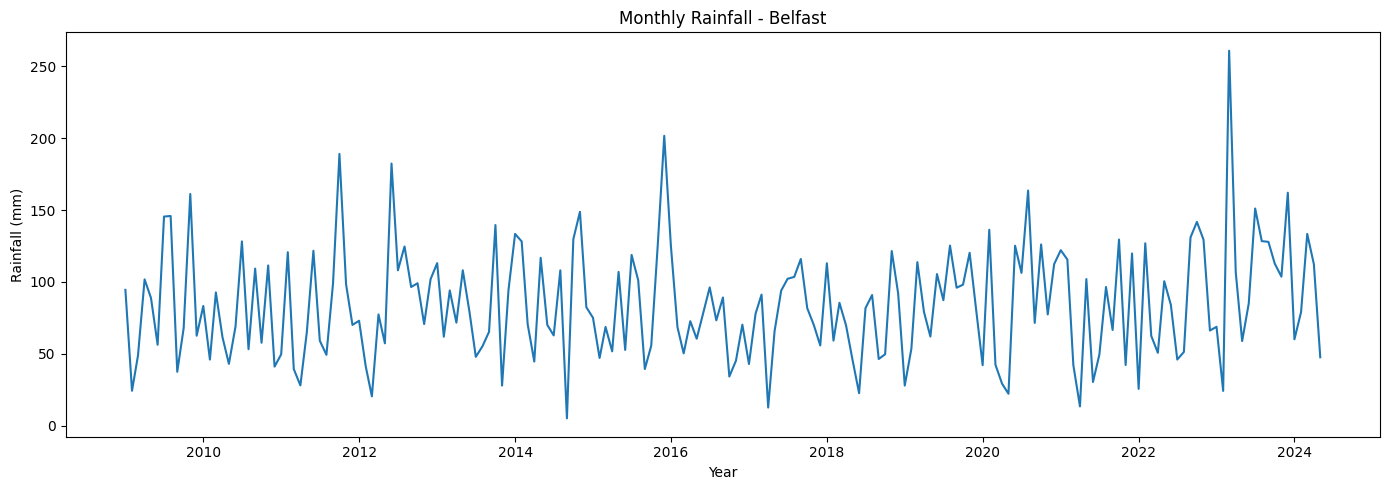

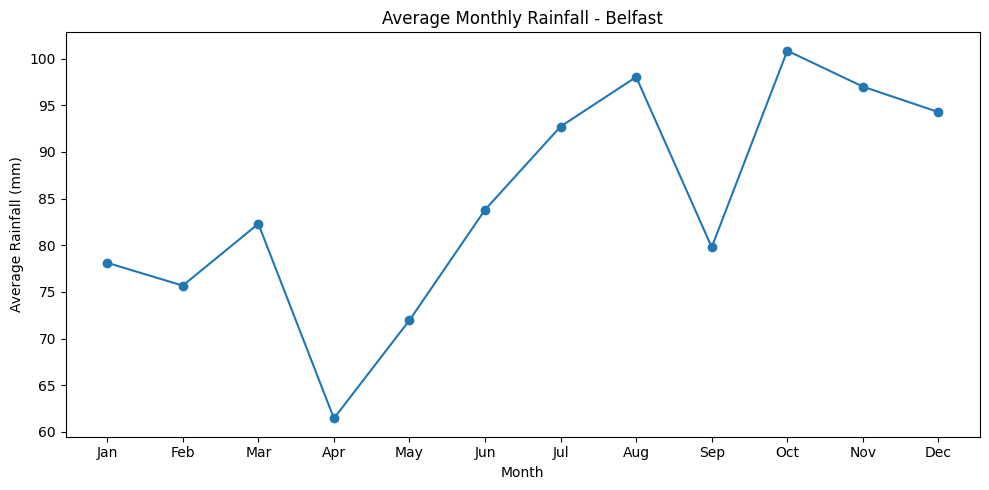

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(y.index, y)
plt.title("Monthly Rainfall - Belfast")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

monthly_average = y.groupby(y.index.month).mean()

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))
plt.plot(
    month_names,
    monthly_average.values,
    marker="o"
)
plt.title("Average Monthly Rainfall - Belfast")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.tight_layout()
plt.show()


## 8. Test stationarity with ADF

The Augmented Dickey-Fuller test evaluates whether the target series contains a unit root.

- **H0:** non-stationary
- **H1:** stationary

If the p-value is below 0.05, the unit-root null is rejected.

For this dataset, the ADF result supports starting with:

**d = 0**

The ADF test addresses ordinary differencing; seasonal differencing `D` is evaluated during SARIMAX validation.


In [7]:
adf_result = adfuller(
    y.dropna(),
    autolag="AIC"
)

print("ADF Statistic:", adf_result[0])
print("p-value      :", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value {key}: {value}")


ADF Statistic: -12.959134062111382
p-value      : 3.2531656187656997e-24
Critical Value 1%: -3.466398230774071
Critical Value 5%: -2.8773796387256514
Critical Value 10%: -2.575213838610586


## 9. Inspect temporal dependence with ACF and PACF

- **ACF** shows correlation with previous values across lags.
- **PACF** shows the direct correlation at each lag after accounting for shorter lags.

For monthly data, lags around **12, 24, 36, and 48** are especially useful when checking annual dependence.

ACF and PACF guide model design, but they are not used as the only model-selection criterion.


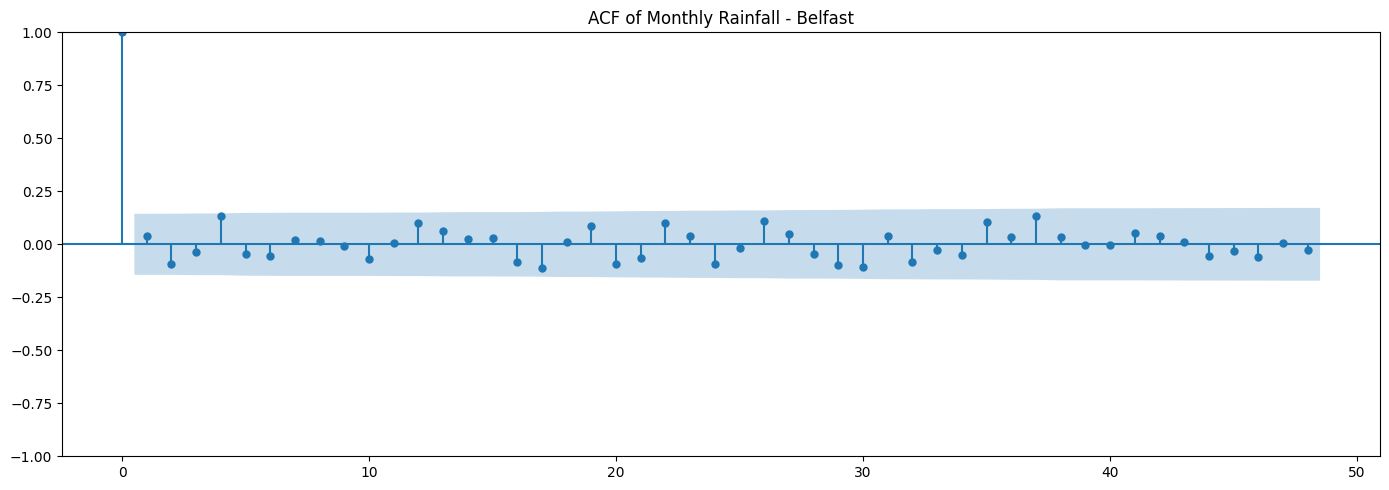

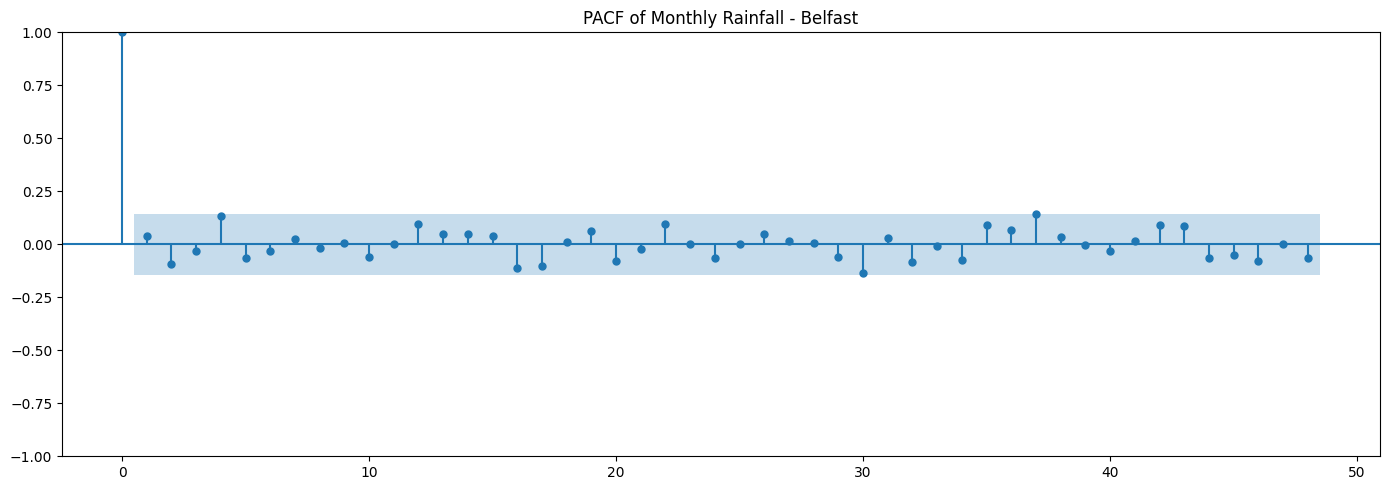

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(y, lags=48, ax=ax)
ax.set_title("ACF of Monthly Rainfall - Belfast")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
plot_pacf(y, lags=48, method="ywm", ax=ax)
ax.set_title("PACF of Monthly Rainfall - Belfast")
plt.tight_layout()
plt.show()


## 10. Create training, validation, and test periods

Time-series observations are never randomly shuffled.

The final **24 months** are reserved as the test set.

Inside the training period, the final **24 months** are used as validation data for SARIMAX parameter and exogenous-set selection.

This design prevents the test period from being used for tuning.

**Sub-training → Validation → Final test**


Sub-training:
2009-01-01 00:00:00 to 2020-05-01 00:00:00 | 137 months

Validation:
2020-06-01 00:00:00 to 2022-05-01 00:00:00 | 24 months

Final test:
2022-06-01 00:00:00 to 2024-05-01 00:00:00 | 24 months


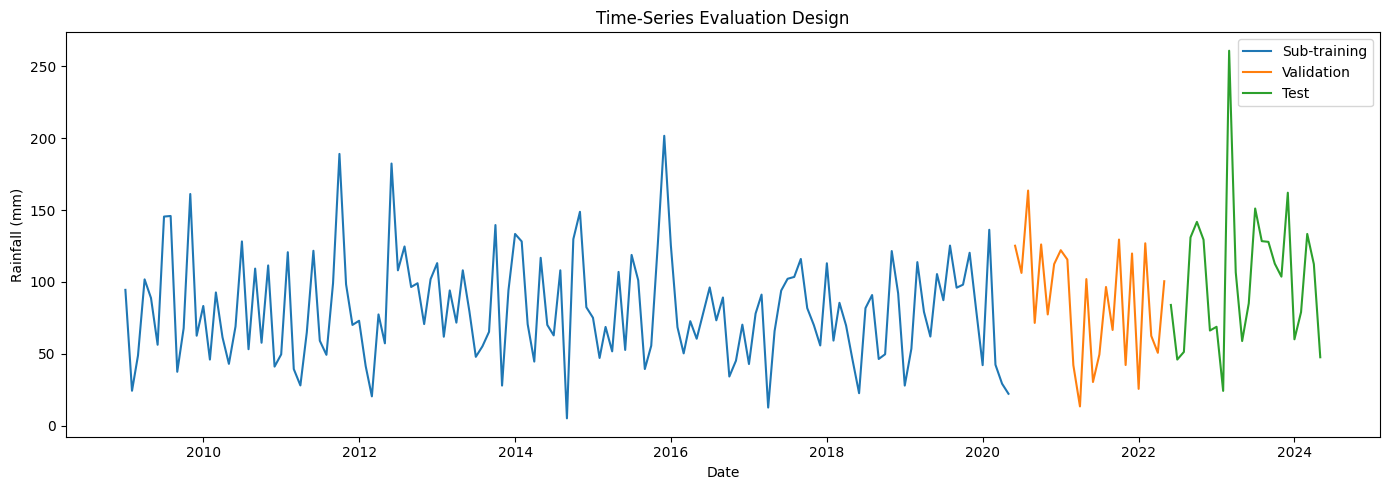

In [9]:
TEST_MONTHS = 24
VALIDATION_MONTHS = 24

y_train = y.iloc[:-TEST_MONTHS]
y_test = y.iloc[-TEST_MONTHS:]

y_subtrain = y_train.iloc[:-VALIDATION_MONTHS]
y_val = y_train.iloc[-VALIDATION_MONTHS:]

print("Sub-training:")
print(y_subtrain.index.min(), "to", y_subtrain.index.max(), "|", len(y_subtrain), "months")

print("\nValidation:")
print(y_val.index.min(), "to", y_val.index.max(), "|", len(y_val), "months")

print("\nFinal test:")
print(y_test.index.min(), "to", y_test.index.max(), "|", len(y_test), "months")

plt.figure(figsize=(14, 5))
plt.plot(y_subtrain, label="Sub-training")
plt.plot(y_val, label="Validation")
plt.plot(y_test, label="Test")
plt.title("Time-Series Evaluation Design")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Prepare exogenous variables without leakage

The exogenous variables are standardized so they are on comparable scales.

For validation, scaling statistics are calculated using **sub-training data only**.

Two predictor sets are compared:

- **5 variables:** minimum temperature, maximum temperature, humidity, cloud cover, wind speed
- **4 variables:** maximum temperature, humidity, cloud cover, wind speed

This allows the model to determine whether removing minimum temperature improves validation performance.


In [10]:
# Full 5-variable set
X_full_subtrain = X_full.loc[y_subtrain.index]
X_full_val = X_full.loc[y_val.index]

full_mean = X_full_subtrain.mean()
full_std = X_full_subtrain.std()

X_full_subtrain_scaled = (
    X_full_subtrain - full_mean
) / full_std

X_full_val_scaled = (
    X_full_val - full_mean
) / full_std

# Reduced 4-variable set
X_red_subtrain = X_reduced.loc[y_subtrain.index]
X_red_val = X_reduced.loc[y_val.index]

red_mean = X_red_subtrain.mean()
red_std = X_red_subtrain.std()

X_red_subtrain_scaled = (
    X_red_subtrain - red_mean
) / red_std

X_red_val_scaled = (
    X_red_val - red_mean
) / red_std

print("Missing values in scaled validation inputs:")
print("5-variable set:", X_full_val_scaled.isna().sum().sum())
print("4-variable set:", X_red_val_scaled.isna().sum().sum())


Missing values in scaled validation inputs:
5-variable set: 0
4-variable set: 0


## 12. Tune SARIMAX on the validation period

A compact grid is used to keep the project transparent and computationally manageable.

The search tests:

- `p, q ∈ {0, 1}`
- `P, D, Q ∈ {0, 1}`
- `d = 0`
- `m = 12`
- both 5-variable and 4-variable exogenous sets

The model with the **lowest validation RMSE** is selected.

AIC is recorded as a diagnostic, but model selection is based on out-of-sample validation error.


In [11]:
p_values = [0, 1]
q_values = [0, 1]

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

tuning_results = []

exog_sets = {
    "5 variables": (
        X_full_subtrain_scaled,
        X_full_val_scaled
    ),
    "4 variables": (
        X_red_subtrain_scaled,
        X_red_val_scaled
    )
}

for exog_name, (X_sub, X_validation) in exog_sets.items():

    for p, q, P, D, Q in itertools.product(
        p_values,
        q_values,
        P_values,
        D_values,
        Q_values
    ):

        order = (p, 0, q)
        seasonal_order = (P, D, Q, 12)

        try:
            model = SARIMAX(
                y_subtrain,
                exog=X_sub,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit = model.fit(
                disp=False,
                maxiter=200
            )

            forecast = fit.forecast(
                steps=len(y_val),
                exog=X_validation
            )

            mae = mean_absolute_error(
                y_val,
                forecast
            )

            rmse = np.sqrt(
                mean_squared_error(
                    y_val,
                    forecast
                )
            )

            tuning_results.append({
                "Exogenous_Set": exog_name,
                "Order": order,
                "Seasonal_Order": seasonal_order,
                "AIC": fit.aic,
                "MAE": mae,
                "RMSE": rmse
            })

        except Exception:
            continue

tuning_table = (
    pd.DataFrame(tuning_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

tuning_table.head(15).round(2)


,Exogenous_Set,Order,Seasonal_Order,AIC,MAE,RMSE
0,5 variables,"(1, 0, 1)","(0, 0, 1, 12)",1177.03,23.32,29.29
1,5 variables,"(1, 0, 1)","(1, 0, 0, 12)",1185.45,23.59,29.55
2,5 variables,"(1, 0, 1)","(1, 0, 1, 12)",1179.00,23.61,29.56
3,5 variables,"(1, 0, 1)","(0, 0, 0, 12)",1299.29,23.55,29.57
4,4 variables,"(1, 0, 1)","(0, 0, 0, 12)",1297.31,23.64,29.70
5,4 variables,"(1, 0, 1)","(1, 0, 0, 12)",1183.45,23.70,29.73
6,4 variables,"(1, 0, 1)","(1, 0, 1, 12)",1181.47,23.69,29.79
7,4 variables,"(1, 0, 1)","(0, 0, 1, 12)",1175.16,23.77,29.80
8,5 variables,"(1, 0, 1)","(1, 1, 1, 12)",1076.89,23.96,30.30
9,4 variables,"(1, 0, 1)","(1, 1, 1, 12)",1075.62,24.15,30.38


## 13. Select the validation winner

The validation search selects:

**SARIMAX(1,0,1)(0,0,1,12)**

with the **5-variable exogenous set**.

In the completed analysis, this model produced:

- Validation MAE ≈ **23.32 mm**
- Validation RMSE ≈ **29.29 mm**

The model specification is now locked before looking at final test performance.


In [12]:
best_validation_model = tuning_table.iloc[0]

selected_exog_set = best_validation_model["Exogenous_Set"]
selected_order = best_validation_model["Order"]
selected_seasonal_order = best_validation_model["Seasonal_Order"]

print("Selected exogenous set:", selected_exog_set)
print("Selected order:", selected_order)
print("Selected seasonal order:", selected_seasonal_order)
print("Validation MAE:", round(best_validation_model["MAE"], 2))
print("Validation RMSE:", round(best_validation_model["RMSE"], 2))
print("AIC:", round(best_validation_model["AIC"], 2))


Selected exogenous set: 5 variables
Selected order: (1, 0, 1)
Selected seasonal order: (0, 0, 1, 12)
Validation MAE: 23.32
Validation RMSE: 29.29
AIC: 1177.03


## 14. Fit comparison models on the full training period

Three approaches are evaluated on the same untouched 24-month test set:

### Seasonal Naive
Repeats the final 12 observed training months.

### SARIMA
Uses rainfall history and seasonal structure but no external predictors.

### Selected SARIMAX
Uses rainfall history, seasonal structure, and the five weather predictors selected through validation.

Lower **MAE** and **RMSE** indicate better forecasting performance.


In [15]:
# --------------------
# Seasonal Naive
# --------------------
last_season = y_train.iloc[-12:].values

seasonal_naive = pd.Series(
    np.tile(
        last_season,
        int(np.ceil(len(y_test) / 12))
    )[:len(y_test)],
    index=y_test.index,
    name="Seasonal Naive"
)

naive_mae = mean_absolute_error(
    y_test,
    seasonal_naive
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        seasonal_naive
    )
)

# --------------------
# SARIMA baseline
# --------------------
sarima_model = SARIMAX(
    y_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(
    disp=False,
    maxiter=200
)

sarima_forecast = sarima_fit.forecast(
    steps=len(y_test)
)

sarima_mae = mean_absolute_error(
    y_test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        sarima_forecast
    )
)

# --------------------
# Selected SARIMAX
# --------------------
X_final_train = X_full.loc[y_train.index]
X_final_test = X_full.loc[y_test.index]

final_X_mean = X_final_train.mean()
final_X_std = X_final_train.std()

X_final_train_scaled = (
    X_final_train - final_X_mean
) / final_X_std

X_final_test_scaled = (
    X_final_test - final_X_mean
) / final_X_std

final_sarimax_model = SARIMAX(
    y_train,
    exog=X_final_train_scaled,
    order=selected_order,
    seasonal_order=selected_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarimax_fit = final_sarimax_model.fit(
    disp=False,
    maxiter=200
)

final_forecast_obj = final_sarimax_fit.get_forecast(
    steps=len(y_test),
    exog=X_final_test_scaled
)

final_sarimax_forecast = (
    final_forecast_obj.predicted_mean
)

final_ci = final_forecast_obj.conf_int()

final_sarimax_mae = mean_absolute_error(
    y_test,
    final_sarimax_forecast
)

final_sarimax_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_sarimax_forecast
    )
)


## 15. Final test performance

The completed analysis produced:

| Model | MAE (mm) | RMSE (mm) |
|---|---:|---:|
| Seasonal Naive | 58.32 | 69.34 |
| SARIMA(1,0,1)(1,0,1,12) | 43.29 | 58.70 |
| **Selected SARIMAX(1,0,1)(0,0,1,12)** | **31.80** | **44.36** |

Relative to SARIMA, the selected SARIMAX reduces:

- MAE by approximately **26.54%**
- RMSE by approximately **24.43%**

This is the main result of the project: the exogenous weather variables add substantial forecasting skill beyond the rainfall-only seasonal model.


In [16]:
final_comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA(1,0,1)(1,0,1,12)",
        "SARIMAX(1,0,1)(0,0,1,12)"
    ],
    "MAE": [
        naive_mae,
        sarima_mae,
        final_sarimax_mae
    ],
    "RMSE": [
        naive_rmse,
        sarima_rmse,
        final_sarimax_rmse
    ]
}).round(2)

display(final_comparison)

mae_improvement = (
    (sarima_mae - final_sarimax_mae)
    / sarima_mae
) * 100

rmse_improvement = (
    (sarima_rmse - final_sarimax_rmse)
    / sarima_rmse
) * 100

print("MAE improvement over SARIMA :", round(mae_improvement, 2), "%")
print("RMSE improvement over SARIMA:", round(rmse_improvement, 2), "%")


,Model,MAE,RMSE
0,Seasonal Naive,58.32,69.34
1,"SARIMA(1,0,1)(1,0,1,12)",43.29,58.70
2,"SARIMAX(1,0,1)(0,0,1,12)",31.80,44.36


MAE improvement over SARIMA : 26.54 %
RMSE improvement over SARIMA: 24.43 %


## 16. Plot the final test forecast

The plot compares the observed test rainfall with SARIMA and the selected SARIMAX forecast.

The 95% confidence interval represents uncertainty around the SARIMAX prediction.


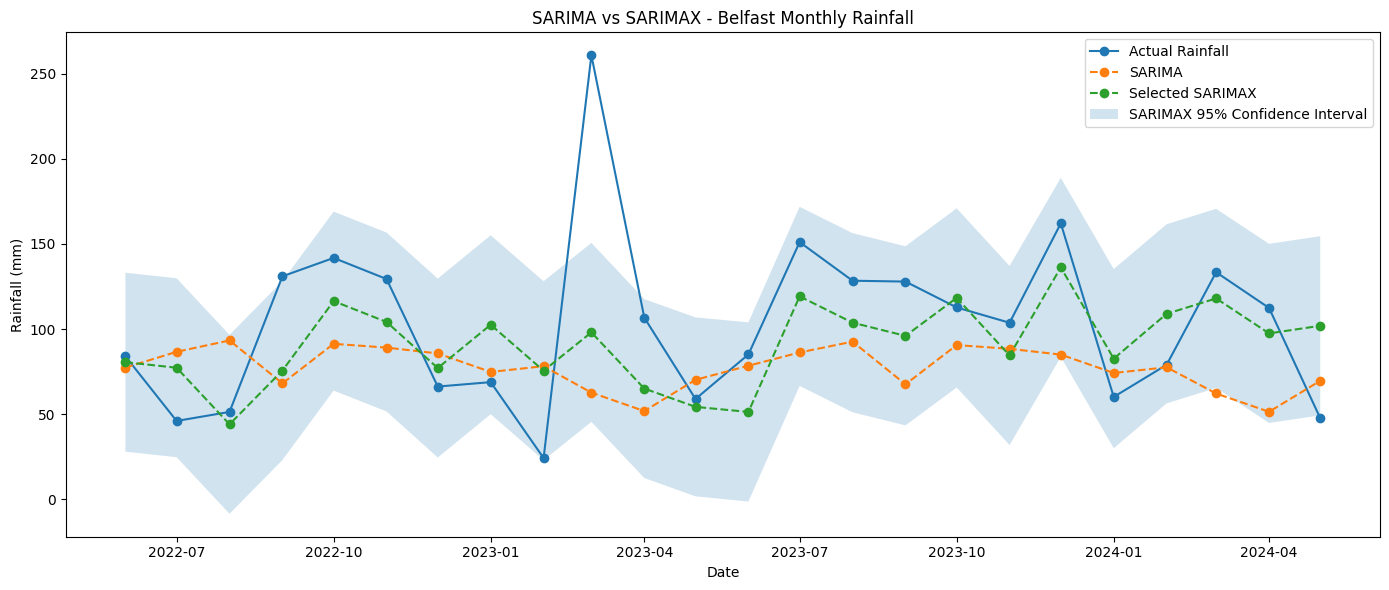

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test,
    marker="o",
    label="Actual Rainfall"
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    linestyle="--",
    marker="o",
    label="SARIMA"
)

plt.plot(
    final_sarimax_forecast.index,
    final_sarimax_forecast,
    linestyle="--",
    marker="o",
    label="Selected SARIMAX"
)

plt.fill_between(
    final_ci.index,
    final_ci.iloc[:, 0],
    final_ci.iloc[:, 1],
    alpha=0.2,
    label="SARIMAX 95% Confidence Interval"
)

plt.title("SARIMA vs SARIMAX - Belfast Monthly Rainfall")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()

plt.tight_layout()
plt.show()


## 17. Residual diagnostics

After forecasting accuracy, we check whether important serial dependence remains in the SARIMAX residuals.

The Ljung-Box test uses:

- **H0:** no residual autocorrelation
- **H1:** residual autocorrelation remains

For the selected model, the completed analysis produced:

- lag 12 p-value ≈ **0.818**
- lag 24 p-value ≈ **0.769**

Both are greater than 0.05, so no significant residual autocorrelation was detected at these seasonal lags.


,lb_stat,lb_pvalue
12,7.564056,0.818203
24,18.673493,0.769171


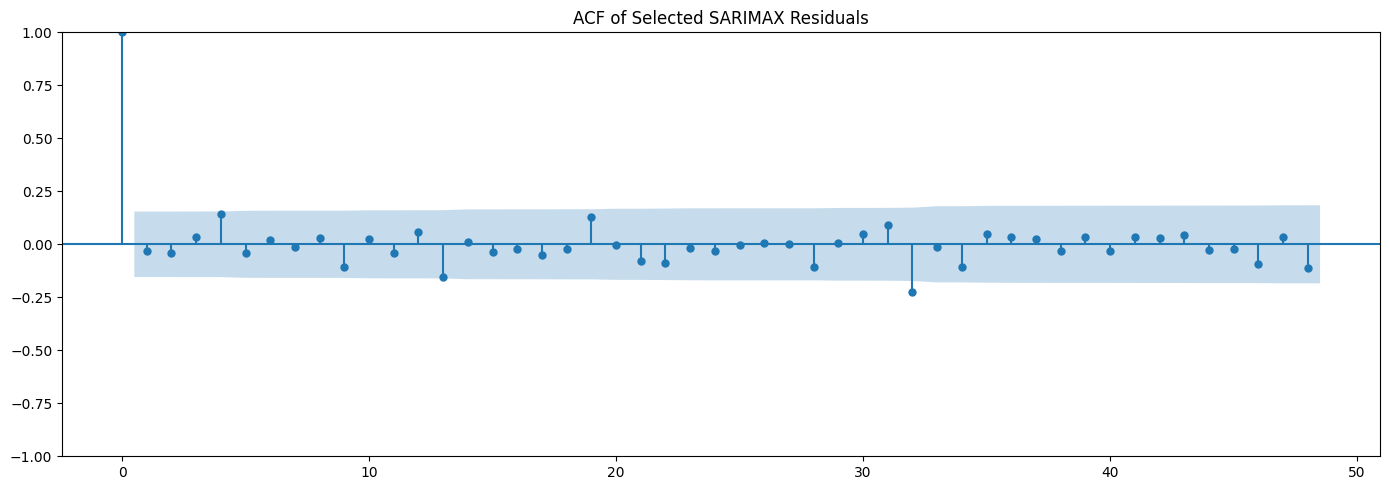

In [18]:
final_residuals = final_sarimax_fit.resid.dropna()

final_lb = acorr_ljungbox(
    final_residuals,
    lags=[12, 24],
    return_df=True
)

display(final_lb)

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    final_residuals,
    lags=48,
    ax=ax
)

ax.set_title("ACF of Selected SARIMAX Residuals")

plt.tight_layout()
plt.show()


## 18. Examine exogenous-variable coefficients

Because the predictors were standardized, their fitted coefficients are on comparable input scales.

In the selected model:

- humidity is statistically significant
- cloud cover is statistically significant
- wind speed is statistically significant
- minimum and maximum temperature are not statistically significant at the 0.05 level

These coefficients describe associations inside this fitted forecasting model. They should **not** be interpreted as causal effects.


In [19]:
final_params = pd.DataFrame({
    "Coefficient": final_sarimax_fit.params,
    "p_value": final_sarimax_fit.pvalues
})

final_exog_results = (
    final_params
    .loc[full_variables]
    .round(4)
)

final_exog_results


,Coefficient,p_value
min_temp_c,-6.8774,0.6384
max_temp_c,20.3396,0.1811
humidity,11.4901,0.0024
cloud_cover,13.9848,0.0000
wind_speed,15.0742,0.0000


## 19. Inspect forecast errors

Monthly forecasting errors help identify periods that are difficult for the model, especially unusual rainfall extremes.


In [20]:
final_forecast_table = pd.DataFrame({
    "Actual_Rainfall": y_test,
    "SARIMA_Forecast": sarima_forecast,
    "SARIMAX_Forecast": final_sarimax_forecast
})

final_forecast_table["SARIMAX_Error"] = (
    final_forecast_table["Actual_Rainfall"]
    - final_forecast_table["SARIMAX_Forecast"]
)

final_forecast_table["Absolute_Error"] = (
    final_forecast_table["SARIMAX_Error"].abs()
)

display(final_forecast_table.round(2))

print("\nLargest SARIMAX errors:")
display(
    final_forecast_table
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
    .round(2)
)


,Actual_Rainfall,SARIMA_Forecast,SARIMAX_Forecast,SARIMAX_Error,Absolute_Error
2022-06-01,84.0,77.36,80.52,3.48,3.48
2022-07-01,46.0,86.62,77.28,-31.28,31.28
2022-08-01,51.3,93.30,44.01,7.29,7.29
2022-09-01,131.0,68.06,75.60,55.40,55.40
2022-10-01,141.8,91.32,116.42,25.38,25.38
2022-11-01,129.4,89.09,104.15,25.25,25.25
2022-12-01,66.2,85.67,77.07,-10.87,10.87
2023-01-01,68.8,74.79,102.54,-33.74,33.74
2023-02-01,24.2,78.16,75.52,-51.32,51.32
2023-03-01,260.9,62.64,98.06,162.84,162.84



Largest SARIMAX errors:


,Actual_Rainfall,SARIMA_Forecast,SARIMAX_Forecast,SARIMAX_Error,Absolute_Error
2023-03-01,260.9,62.64,98.06,162.84,162.84
2022-09-01,131.0,68.06,75.60,55.40,55.40
2024-05-01,47.6,69.61,101.92,-54.32,54.32
2023-02-01,24.2,78.16,75.52,-51.32,51.32
2023-04-01,106.7,51.80,65.02,41.68,41.68
2023-06-01,85.1,78.45,51.29,33.81,33.81
2023-01-01,68.8,74.79,102.54,-33.74,33.74
2023-09-01,127.9,67.52,96.00,31.90,31.90
2023-07-01,151.1,86.24,119.21,31.89,31.89
2022-07-01,46.0,86.62,77.28,-31.28,31.28


## 20. Why this notebook does not make an unconditional future SARIMAX forecast

SARIMAX requires future values of the exogenous predictors.

For example, to forecast future rainfall, the model would also need future:

- temperature
- humidity
- cloud cover
- wind speed

Those values are not known automatically.

A true future SARIMAX forecast therefore requires one of the following:

1. known future meteorological inputs,
2. separate forecasts of the exogenous variables, or
3. clearly defined future scenarios.

Using actual future `X` values is appropriate for the held-out test experiment because it measures the conditional forecasting value of those predictors. It should not be presented as an unconditional operational future forecast.


# Key learning outcomes

After completing this project, focus on these ideas:

1. **SARIMAX = SARIMA + external predictors.**
2. `y` is the target; `X` contains the exogenous variables.
3. Monthly data use a seasonal period of `m = 12`.
4. Exogenous variables must be scaled using training information only.
5. Hyperparameters should be selected on validation data, not the final test period.
6. A model should be compared with simpler baselines.
7. Residual diagnostics complement forecast-error metrics.
8. Future SARIMAX forecasts require future exogenous inputs.
9. Forecasting coefficients describe model associations, not causality.

## Final result

For this Belfast dataset, adding meteorological exogenous variables substantially improved monthly rainfall forecasting compared with the rainfall-only SARIMA baseline.
